# <center>Практика. Статистические тесты в контексте EDA

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

### Ключевые вопросы HR-агентства:

* Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
* Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
* Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
* Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

Ответить на эти вопросы помогут данные о зарплатах в сфере Data Science за 2020–2022.

Данные содержат следующие столбцы:

* work_year - Год, в котором была выплачена зарплата;
* experience_level - Опыт работы на этой должности в течение года со следующими возможными значениями:
    * EN — Entry-level/Junior;
    * MI — Mid-level/Intermediate;
    * SE — Senior-level/Expert;
    * EX — Executive-level/Director.
* employment_type - Тип трудоустройства для этой роли:
    * PT — неполный рабочий день;
    * FT — полный рабочий день;
    * CT — контракт;
    * FL — фриланс.
* job_title - Роль, в которой соискатель работал в течение года;
* salary - Общая выплаченная валовая сумма заработной платы;
* salary_currency - Валюта выплачиваемой заработной платы в виде кода валюты ISO 4217;
* salary_in_usd - Зарплата в долларах США (валютный курс, делённый на среднее значение курса доллара США за соответствующий год через fxdata.foorilla.com);
* employee_residence - Основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166;
* remote_ratio - Общий объём работы, выполняемой удалённо. Возможные значения:
    * 0 — удалённой работы нет (менее 20 %);
    * 50 — частично удалённая работа;
    * 100 — полностью удалённая работа (более 80 %).
* company_location - Страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166;
* company_size - Среднее количество людей, работавших в компании в течение года:
    * S — менее 50 сотрудников (небольшая компания);
    * M — от 50 до 250 сотрудников (средняя компания);
    * L — более 250 сотрудников (крупная компания).

Оригинальный датасет: [“Data Science Job Salaries” (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## 1.Загрузка и обработка данных

In [35]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [36]:
# загружаем датасет
data = pd.read_csv('data/ds_salaries.csv')
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [37]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


В датасете 607 записей (без пропущенных значений).

Проверим данные на наличие полных дубликатов:

In [39]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

Количество дубликатов: 0


К категориальным признакам относятся:
* work_year; 
* experience_level; 
* employment_type; 
* job_title; 
* salary_currency; 
* employee_residence; 
* remote_ratio; 
* company_location; 
* company_size.

К числовым признам относятся:
* salary; 
* salary_in_usd.

Для отвена на поставленные вопросы данные признаки будут неинформативными:

* employee_residence - Основная страна проживания сотрудника в течение рабочего года;
* company_location - Страна главного офиса работодателя или филиала по контракту;
* experience_level - Опыт работы на этой должности в течение года;
* employment_type - Тип трудоустройства;
* remote_ratio - Общий объём работы, выполняемой удалённо.

Для удобства анализа будем рассматривать зарплату  только в долларах США (salary_in_usd). А так же удалим признак Unnamed: 0.

In [42]:
data = data.drop(columns = ['Unnamed: 0'], axis = 1)

## 2.Разведывательный анализ данных

### 2.1. Визуальный анализ данных

#### Распределение заработной платы по всем соискателям

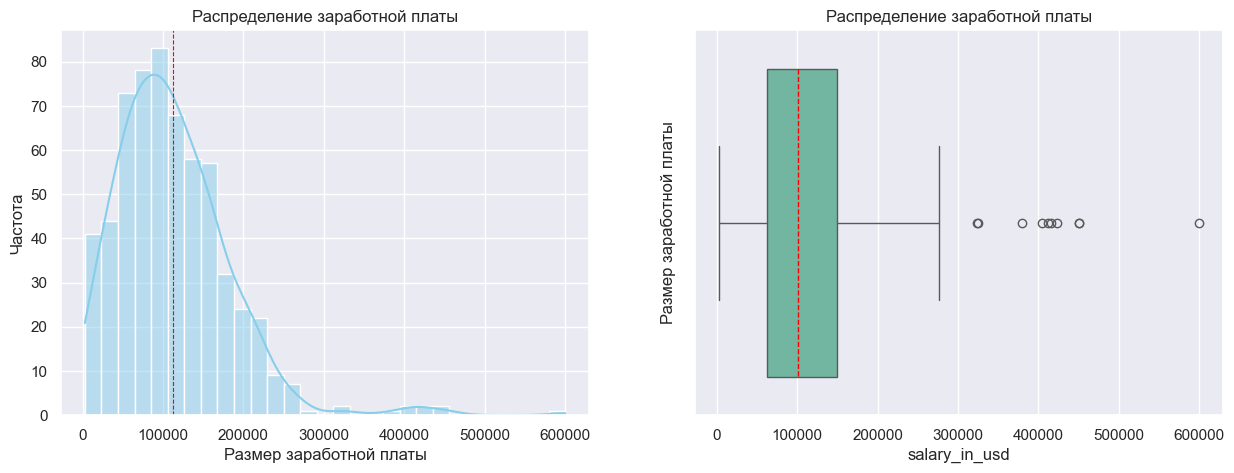

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0], color='skyblue')
axes[0].set(xlabel='Размер заработной платы', ylabel='Частота')
axes[0].set_title('Распределение заработной платы')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='Размер заработной платы')
axes[1].set_title('Распределение заработной платы')

plt.show()

In [44]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Размер заработной платы']
data_agg

,Размер заработной платы
count,607.00
mean,112297.87
std,70957.26
min,2859.00
25%,62726.00
50%,101570.00
75%,150000.00
max,600000.00


Распределение отлично от нормального, имеются выбросы.

#### Заработная плата в зависимости от года

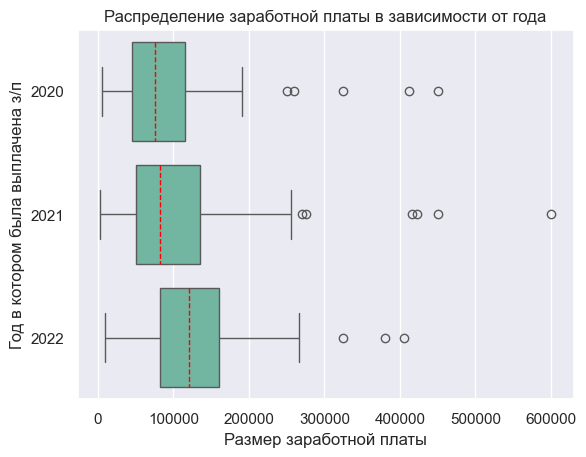

In [45]:
ax = sns.boxplot(data, x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер заработной платы', ylabel='Год в котором была выплачена з/п')
plt.title('Распределение заработной платы в зависимости от года')
plt.show()

In [46]:
data_agg = data.groupby('work_year')['salary_in_usd'].describe().round(2)
print('Заработная плата в зависимости от года')
data_agg

Заработная плата в зависимости от года


,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,72.0,95813.00,82831.80,5707.0,45724.5,75544.0,115526.0,450000.0
2021,217.0,99853.79,80225.11,2859.0,50000.0,82528.0,135000.0,600000.0
2022,318.0,124522.01,58183.65,10000.0,81666.0,120000.0,160000.0,405000.0


Распределения страховых выплат для разных годов различны. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

#### Соотношение зарплаты Data Scientist и Data Engineer в 2022 году 

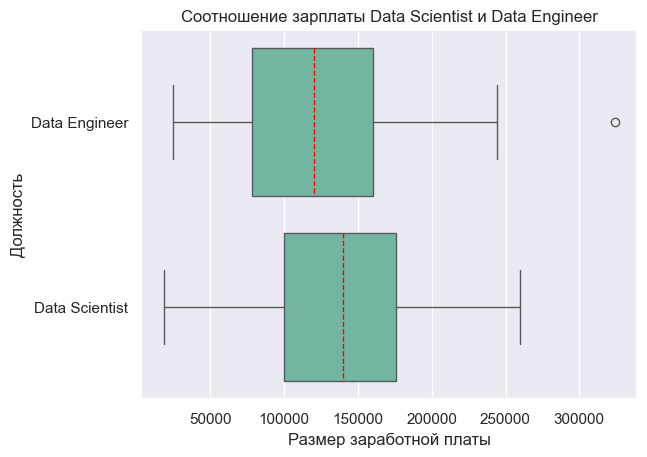

In [79]:
filtered_data = data[(data['work_year'] == 2022) & 
                   (data['job_title'].isin(['Data Scientist', 'Data Engineer']))]
ax = sns.boxplot(filtered_data, x='salary_in_usd', y='job_title', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер заработной платы', ylabel='Должность')
plt.title('Соотношение зарплаты Data Scientist и Data Engineer')
plt.show()

In [80]:
data_agg = filtered_data.groupby('job_title')['salary_in_usd'].describe().round(2)
print('Соотношение зарплаты Data Scientist и Data Engineer')
data_agg

Соотношение зарплаты Data Scientist и Data Engineer


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,89.0,126375.70,55954.40,25000.0,78526.0,120000.0,160000.0,324000.0
Data Scientist,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


Распределения заработной платы для Data Scientist и Data Engineer в 2022 году . Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

#### Заработная плата в зависимости от размера компании

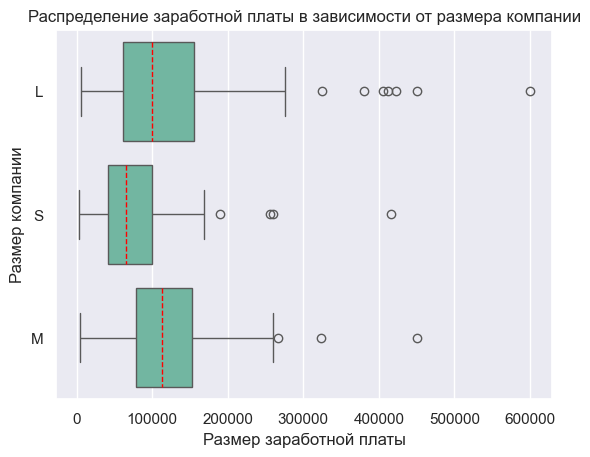

In [81]:
ax = sns.boxplot(data, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер заработной платы', ylabel='Размер компании')
plt.title('Распределение заработной платы в зависимости от размера компании')
plt.show()

In [82]:
data_agg = data.groupby('company_size')['salary_in_usd'].describe().round(2)
print('Заработная плата в зависимости от размера компании')
data_agg

Заработная плата в зависимости от размера компании


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,198.0,119242.99,86156.74,5882.0,61041.75,100000.0,154600.0,600000.0
M,326.0,116905.47,59287.69,4000.0,78131.50,113188.0,152875.0,450000.0
S,83.0,77632.67,63461.71,2859.0,41943.00,65000.0,100000.0,416000.0


На первый взгляд распределения заработной платы в зависимости от размера компании различны. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

#### Соотношение должностей Data Scientist и Data Engineer в компаниях разных размеров

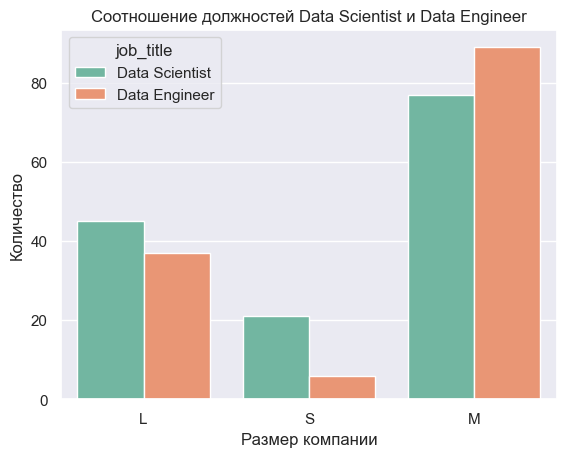

In [83]:
data_roles = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])]
ax = sns.countplot(data=data_roles, x=data['company_size'], hue='job_title')
ax.set(xlabel='Размер компании', ylabel='Количество')
plt.title('Соотношение должностей Data Scientist и Data Engineer')
plt.show()

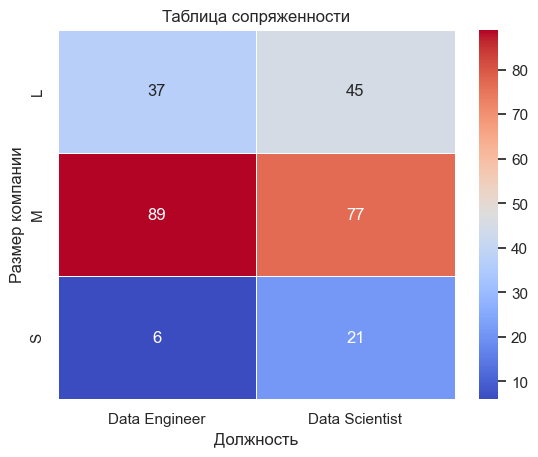

In [86]:
cross_tab = pd.crosstab(index=data_roles['company_size'], columns=data_roles['job_title'])
ax = sns.heatmap(cross_tab, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel='Должность', ylabel='Размер компании')
plt.title('Таблица сопряженности')
plt.show()

Согласно данным, среди крупных и небольших компаний Data Scientist больше, Data Engineer. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

### 2.2. Статистический анализ данных

In [55]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
      

### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы в 2020 году ($μ_1$) статистически больше либо равен размеру заработной платы в 2022 году ($μ_2$).

$$ H_0 : μ_1 >=  μ_2$$

*Альтернативная гипотеза* ($H_1$): размер заработной платы в 2020 году ($μ_1$) статистически меньше размера заработной платы в 2022 году ($μ_2$).

$$ H_1 : μ_1 < μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [62]:
# значения заработной платы
salary_earlier = data.loc[data['work_year']==2020, 'salary_in_usd']
salary_now = data.loc[data['work_year']==2022, 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('В 2020 году:')
result = stats.shapiro(salary_earlier)
decision_normality(result[1])

print('В 2022 году:')
result = stats.shapiro(salary_now)
decision_normality(result[1])

В 2020 году:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
В 2022 году:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата в долларах США »? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать U-критерий Манна — Уитни.

**Проведём тест**

In [63]:
_, p = stats.mannwhitneyu(salary_earlier, salary_now)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Размер заработной платы в 2022 году больше, чем в 2020. Соответственно можно сказать, что ежегодно размер заработной платы растёт.


### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы в 2022 году для Data Scientist($μ_1$) статистически больше либо равен размеру заработной платы в 2022 году для Data Engineer($μ_2$).

$$ H_0 : μ_1 >=  μ_2$$

*Альтернативная гипотеза* ($H_1$): размер заработной платы в 2020 году  для Data Scientist($μ_1$) статистически меньше размера заработной платы в 2022 году для Data Engineer($μ_2$).

$$ H_1 : μ_1 < μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [70]:
year_data = data[(data['work_year'] == 2022)]
# значения заработной платы
ds_salary = year_data.loc[data['job_title']=='Data Scientist', 'salary_in_usd']
de_salary = year_data.loc[data['job_title']=='Data Engineer', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Data Scientist:')
result = stats.shapiro(ds_salary)
decision_normality(result[1])

print('Data Engineer:')
result = stats.shapiro(de_salary)
decision_normality(result[1])

Data Scientist:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата в долларах США »? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать U-критерий Манна — Уитни.

**Проведём тест**

In [71]:
_, p = stats.mannwhitneyu(ds_salary, de_salary)
decision_hypothesis(p)

p-value = 0.155
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Размер заработной платы в 2022 году для Data Scientist выше, чем у Data Engineer.

### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы для Data Scientist не отличается в команиях разных размеров: в небольших компаниях($μ_1$), средних компаниях($μ_2$) и крупных компаниях($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза* ($H_1$): размер заработной платы для Data Scientist отличается в команиях разных размеров: в небольших компаниях($μ_1$), средних компаниях($μ_2$) и крупных компаниях($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [75]:
# значения заработной платы
s_company = data.loc[data['company_size']=='S', 'salary_in_usd']
m_company = data.loc[data['company_size']=='M', 'salary_in_usd']
l_company = data.loc[data['company_size']=='L', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('В небольших компаниях:')
result = stats.shapiro(s_company)
decision_normality(result[1])

print('В средних компаниях:')
result = stats.shapiro(m_company)
decision_normality(result[1])

print('В крупных компаниях:')
result = stats.shapiro(l_company)
decision_normality(result[1])

В небольших компаниях:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
В средних компаниях:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
В крупных компаниях:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата в долларах США»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [76]:
_, p = stats.kruskal(s_company, m_company, l_company)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Размер заработной платы в компаниях разных размеров для Data Scientist отличается.

### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: между наличием должностей Data Scientist и Data Engineer и размером компании нет взаимосвязи (признаки независимы).

*Альтернативная гипотеза*: между наличием должностей Data Scientist и Data Engineer и размером компании есть взаимосвязь (признаки зависимы).

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер компании»? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).


In [87]:
# составляем таблицу сопряжённости
table = pd.crosstab(data_roles['job_title'], data_roles['company_size'])

table

company_size,L,M,S
job_title,,,
Data Engineer,37,89,6
Data Scientist,45,77,21


In [88]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(table)
decision_hypothesis(p)

p-value = 0.008
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Существует статистически значимая взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании.

### 3. Соответствие выводов бизнес-вопросам

* Размер заработной платы  у специалистов Data Scientist ежегодно растет;
* Размер заработной платы в 2022 году для Data Scientist выше, чем у Data Engineer;
* Размер заработной платы в компаниях разных размеров для Data Scientist отличается;
* Существует статистически значимая взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании.

### 4. Дополнительное исследование

#### Как соотносятся зарплаты специалистов Data Scientist в зависимости от опыта работы?

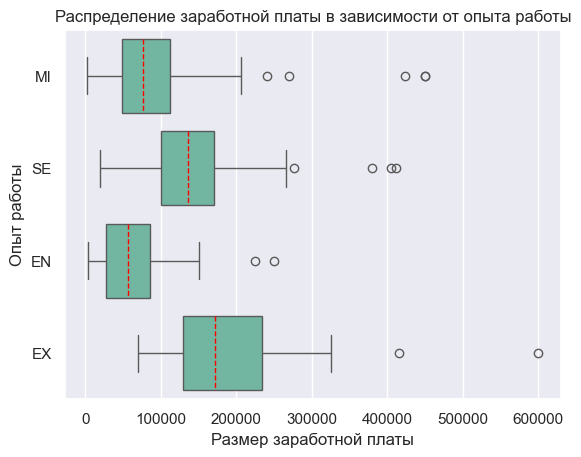

In [94]:
ax = sns.boxplot(data, x='salary_in_usd', y='experience_level', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер заработной платы', ylabel='Опыт работы')
plt.title('Распределение заработной платы в зависимости от опыта работы')
plt.show()

In [95]:
data_agg = data.groupby('experience_level')['salary_in_usd'].describe().round(2)
print('Заработная плата в зависимости от опыта работы')
data_agg

Заработная плата в зависимости от опыта работы


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,88.0,61643.32,44395.54,4000.0,27505.0,56500.0,85425.75,250000.0
EX,26.0,199392.04,117071.26,69741.0,130006.5,171437.5,233750.00,600000.0
MI,213.0,87996.06,63901.06,2859.0,48000.0,76940.0,112000.00,450000.0
SE,280.0,138617.29,57691.98,18907.0,100000.0,135500.0,170000.00,412000.0


Распределения заработной платы в зависимости от опыта работы. Чтобы определить, являются ли эти различия статистически значимыми мы проведём статистические тесты.

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер заработной платы не отличается в зависимости от опыта работы:  Entry-level/Junior ($μ_1$), Mid-level/Intermediate ($μ_2$), Senior-level/Expert ($μ_3$), Executive-level/Director ($μ_4$).

$$ H_0 : μ_1 = μ_2 = μ_3 = μ_4$$

*Альтернативная гипотеза*: размер заработной платы отличается в зависимости от опыта работы:  Entry-level/Junior ($μ_1$), Mid-level/Intermediate ($μ_2$), Senior-level/Expert ($μ_3$), Executive-level/Director ($μ_4$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 \neq μ_4$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [97]:
# значения заработной платы
en_salary = data.loc[data['experience_level']=='EN', 'salary_in_usd']
mi_salary = data.loc[data['experience_level']=='MI', 'salary_in_usd']
se_salary = data.loc[data['experience_level']=='SE', 'salary_in_usd']
ex_salary = data.loc[data['experience_level']=='EX', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для Entry-level/Junior:')
result = stats.shapiro(en_salary)
decision_normality(result[1])

print('Для Mid-level/Intermediate:')
result = stats.shapiro(mi_salary)
decision_normality(result[1])

print('Для Senior-level/Expert:')
result = stats.shapiro(se_salary)
decision_normality(result[1])

print('Для Executive-level/Director:')
result = stats.shapiro(ex_salary)
decision_normality(result[1])

Для Entry-level/Junior:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Mid-level/Intermediate:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Senior-level/Expert:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Executive-level/Director:
p-value = 0.001
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата в долларах США»? — Количественный.
* Сколько сравниваемых групп? — Четыре.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [98]:
# проводим тест
_, p = stats.kruskal(en_salary, mi_salary, se_salary, ex_salary)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Размер заработной платы отличается в зависимости от опыта работы.

### Как соотносятся зарплаты Data Scientist и Data Analyst в 2022 году?

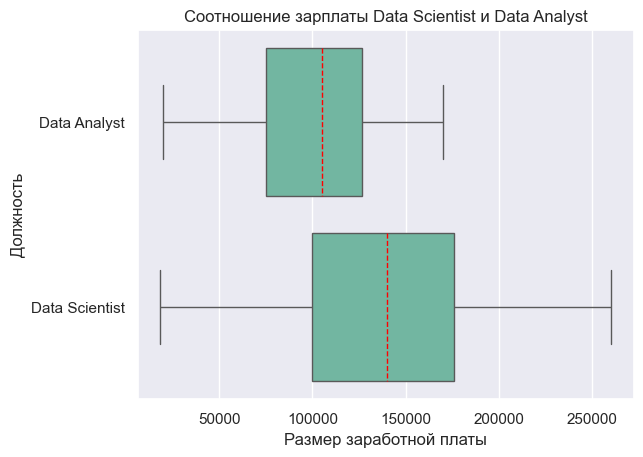

In [100]:
filter_data = data[(data['work_year'] == 2022) & 
                   (data['job_title'].isin(['Data Scientist', 'Data Analyst']))]
ax = sns.boxplot(filter_data, x='salary_in_usd', y='job_title', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер заработной платы', ylabel='Должность')
plt.title('Соотношение зарплаты Data Scientist и Data Analyst')
plt.show()

In [101]:
data_agg = filter_data.groupby('job_title')['salary_in_usd'].describe().round(2)
print('Соотношение зарплаты Data Scientist и Data Analyst')
data_agg

Соотношение зарплаты Data Scientist и Data Analyst


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Analyst,73.0,100550.74,36488.32,20000.0,75000.0,105000.0,126500.0,170000.0
Data Scientist,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


Распределения заработной платы для Data Scientist и Data Engineer в 2022 году . Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

### Как соотносятся зарплаты Data Scientist и Data Analyst в 2022 году?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы в 2022 году для Data Scientist($μ_1$) статистически больше либо равен размеру заработной платы в 2022 году для Data Analyst($μ_2$).

$$ H_0 : μ_1 >=  μ_2$$

*Альтернативная гипотеза* ($H_1$): размер заработной платы в 2020 году  для Data Scientist($μ_1$) статистически меньше размера заработной платы в 2022 году для Data Analyst($μ_2$).

$$ H_1 : μ_1 < μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [104]:
year_data = data[(data['work_year'] == 2022)]
# значения заработной платы
ds_salary = year_data.loc[data['job_title']=='Data Scientist', 'salary_in_usd']
da_salary = year_data.loc[data['job_title']=='Data Analyst', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Data Scientist:')
result = stats.shapiro(ds_salary)
decision_normality(result[1])

print('Data Analyst:')
result = stats.shapiro(da_salary)
decision_normality(result[1])

Data Scientist:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Data Analyst:
p-value = 0.255
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата в долларах США »? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Да. 

Для проверки нашей гипотезы можно использовать двухвыборочный t-критерий.

**Проведём тест**

In [106]:
# проводим тест Левена на равенство дисперсий
print('Тест на равенство дисперсий')
result = stats.levene(ds_salary, da_salary)
p = result[1]
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('Дисперсии не одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=False.')
else:
    print('Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.')

Тест на равенство дисперсий
p-value = 0.005
Дисперсии не одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=False.


In [109]:
# проводим тест на сравнение средних в группах
_, p = stats.ttest_ind(ds_salary, da_salary, alternative='less', equal_var=False)

decision_hypothesis(p)

p-value = 1.000
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Размер заработной платы в 2022 году для Data Scientist статистически больше либо равен размеру заработной платы в 2022 году для Data Analyst.